# <a id='toc1_'></a>[Realtime Example Notebook w/ OpenBCI Cyton Board](#toc0_)

This notebook demonstrates how to get started with python & the openBCI cyton board. We will use the brainflow library as a backend to interface with the board and acquire data, however I have created a custom module to make it easier to use brainflow with the cyton board. This notebook will show you how to set up the board, start a stream, and visualize the data in real-time.

**NOTE:** If you want to use the custom module, you will need to have the file `brainflow_stream.py` in the same directory as this notebook (or other scripts that use it).

**Table of contents**
- [Realtime Example Notebook w/ OpenBCI Cyton Board](#toc1_)
  - [Installation](#toc1_1_)
- [Connecting to the cyton board](#toc2_)
  - [Create a BrainFlowBoard object](#toc2_1_)
  - [Get Data](#toc2_2_)
- [Basic data processing (DC offset)](#toc3_)
- [Event Markers](#toc4_)
- [Band Powers & Engagement Index](#toc5_)
  - [Bandpowers](#toc5_1_)
  - [Engagement Index (real-time loop)](#toc5_2_)
- [Resources](#toc7_)


## <a id='toc1_1_'></a>[Installation](#toc0_)

Make sure you have the provided `neurohack` python environment installed.

Or you can install the following packages:

```bash
conda/pip install brainflow scipy matplotlib pyserial jupyterlab
```

In [2]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

import brainflow
from brainflow.board_shim import BoardShim, BrainFlowInputParams, BrainFlowError, BoardIds


# Import the custom module.
from brainflow_stream import BrainFlowBoardSetup

# <a id='toc2_'></a>[Connecting to the cyton board](#toc0_)

## <a id='toc2_1_'></a>[Create a BrainFlowBoard object](#toc0_)

The 'BrainFlowBoardSetup()' object is a custom wrapper to the Brainflow BoardShim object. There is some added utility to the custom wrapper, such as the ability to automatically detect the serial port of the Cyton board.

For specifics on the custom class, expand below or see the `brainflow_stream.py` module for more details.

<details>
<summary>Expand for more details on the `BrainFlowBoardSetup()` object</summary>

#### <a id='toc2_1_1_1_'></a>[Parameters](#toc0_)
- **board_id** (*int*): ID of the BrainFlow board.
- **name** (*str*, optional): User-friendly identifier (useful when connecting to multiple boards).
- **serial_port** (*str*, optinoal): Serial port for the BrainFlow board.
- **master_board** (*int*, optional): ID of the master board (playback/synthetic only).
- **params** (*BrainFlowInputParams*, optional): Input parameters for the board.

</details>

In [3]:
board_id = BoardIds.CYTON_BOARD.value # Set the board_id to match the Cyton board

# Lets quickly take a look at the specifications of the Cyton board
for item1, item2 in BoardShim.get_board_descr(board_id).items():
    print(f"{item1}: {item2}")

accel_channels: [9, 10, 11]
analog_channels: [19, 20, 21]
ecg_channels: [1, 2, 3, 4, 5, 6, 7, 8]
eeg_channels: [1, 2, 3, 4, 5, 6, 7, 8]
eeg_names: Fp1,Fp2,C3,C4,P7,P8,O1,O2
emg_channels: [1, 2, 3, 4, 5, 6, 7, 8]
eog_channels: [1, 2, 3, 4, 5, 6, 7, 8]
marker_channel: 23
name: Cyton
num_rows: 24
other_channels: [12, 13, 14, 15, 16, 17, 18]
package_num_channel: 0
sampling_rate: 250
timestamp_channel: 22


In [4]:
cyton_board = BrainFlowBoardSetup(
                                board_id = board_id,
                                name = 'Board_1',   # Optional name for the board. This is useful if you have multiple boards connected and want to distinguish between them.
                                serial_port = 'COM4'  # If the serial port is not specified, it will try to auto-detect the board. If this fails, you will have to assign the correct serial port. See https://docs.openbci.com/GettingStarted/Boards/CytonGS/ 
                                ) 

cyton_board.setup() # This will establish a connection to the board and start streaming data.

[Board_1, COM4] Board setup and streaming started successfully.


Once the board is connected and streaming, we can call some utility functions to get some information about the board.

In [6]:
board_info = cyton_board.get_board_info() # Retrieves the EEG channel and sampling rate of the board.
print(f"Board info: {board_info}")

board_srate = cyton_board.get_sampling_rate() # Retrieves the sampling rate of the board.
print(f"Board sampling rate: {board_srate}")

Board info: ([1, 2, 3, 4, 5, 6, 7, 8], 250)
Board sampling rate: 250


We can also look at the specifications of the board.

## <a id='toc2_2_'></a>[Get Data](#toc0_)

Once connected, the board starts streaming data into the computers' buffer where it is stored temporarily. The default buffer size is 450000 (at 250Hz sampling rate, this is 30 minutes). We can then pull data from the buffer and process it.

There are **Two ways** to pull data from the board/buffer.
1. 'get_board_data()' -> Retrieves and clears ALL samples from the buffer. 
2. 'get_current_board_data(num_samples)' -> Retrieves the last 'num_samples' samples without clearing them from the buffer.

For more information on the buffer and behind-the-scenes see the [brainflow documentation](https://brainflow.readthedocs.io/en/stable/UserAPI.html#brainflow-board-shim).

In [7]:
time.sleep(5) # Wait for 5 seconds to allow the board to build up some samples into the buffer

raw_data_500 = cyton_board.get_current_board_data(num_samples = 500) # Get the latest 500 samples from the buffer
print(f"raw_data_1000 shape: {raw_data_500.shape}")

raw_data_all = cyton_board.get_board_data() 
print(f"raw_data_all shape: {raw_data_all.shape}")

raw_data_1000 shape: (24, 500)
raw_data_all shape: (24, 3487)


As we can see here, each method returns a tuple of two arrays in shape **(n_channels, n_samples)**

Since the cyton_board only has 8 eeg channels, the other channels contain data on other sensors like the accelerometer, gyroscope, etc.

For the Cyton boards this is the channel mapping:
- {'accel_channels': [9, 10, 11], 
- 'analog_channels': [19, 20, 21], 
- 'eeg_channels': [1, 2, 3, 4, 5, 6, 7, 8], 
- 'eeg_names': 'Fp1,Fp2,C3,C4,P7,P8,O1,O2', 
- 'marker_channel': 23, 
- 'other_channels': [12, 13, 14, 15, 16, 17, 18], 
- 'package_num_channel': 0, 
- 'sampling_rate': 250, 
- 'timestamp_channel': 22}

So, lets slice out only the EEG channels from our raw data

In [8]:
eeg_data = raw_data_500[1:9, :] # Get the EEG data from the first 8 channels
print(f"eeg_data shape: {eeg_data.shape}")


eeg_data shape: (8, 500)


Great, now lets visualize the data using matplotlib

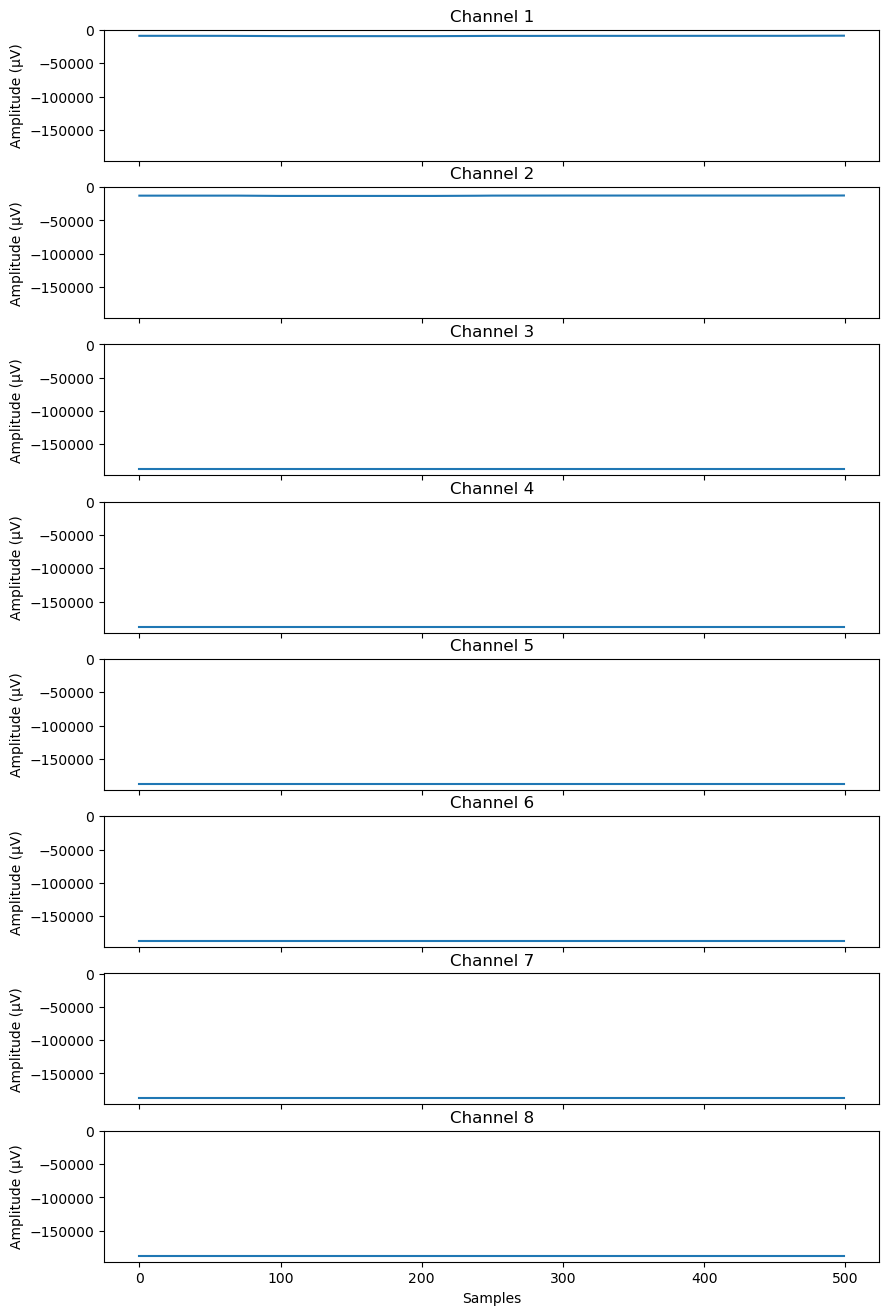

In [9]:
num_channels = eeg_data.shape[0]
num_samples = eeg_data.shape[1]

# Create a figure and a set of subplots
fig, axes = plt.subplots(num_channels, 1, figsize=(10, 2 * num_channels), sharex=True, sharey=True)

# Plot each channel
for i in range(num_channels):
    axes[i].plot(eeg_data[i, :])
    axes[i].set_title(f'Channel {i+1}')
    axes[i].set_ylabel('Amplitude (µV)')

axes[-1].set_xlabel('Samples')

plt.show()

# <a id='toc3_'></a>[Basic data processing (DC offset)](#toc0_)

If you look at the above graph of the raw data, the X-axis looks off - those values are far too large! Let's normalize the data so that it's centered around 0. 

In [11]:
# To do this we can subtract the mean of the data from the data itself. This will center the data around zero.
eeg_data_dc_removed = eeg_data - np.mean(eeg_data, axis=1, keepdims=True)

# While we're at it, lets make a small function that performs all of our minimal processing this since we'll have to do it every time we pull data from the board.
def remove_dc_offset(data):
    return data[1:9, :] - np.mean(data[1:9, :], axis=1, keepdims=True)

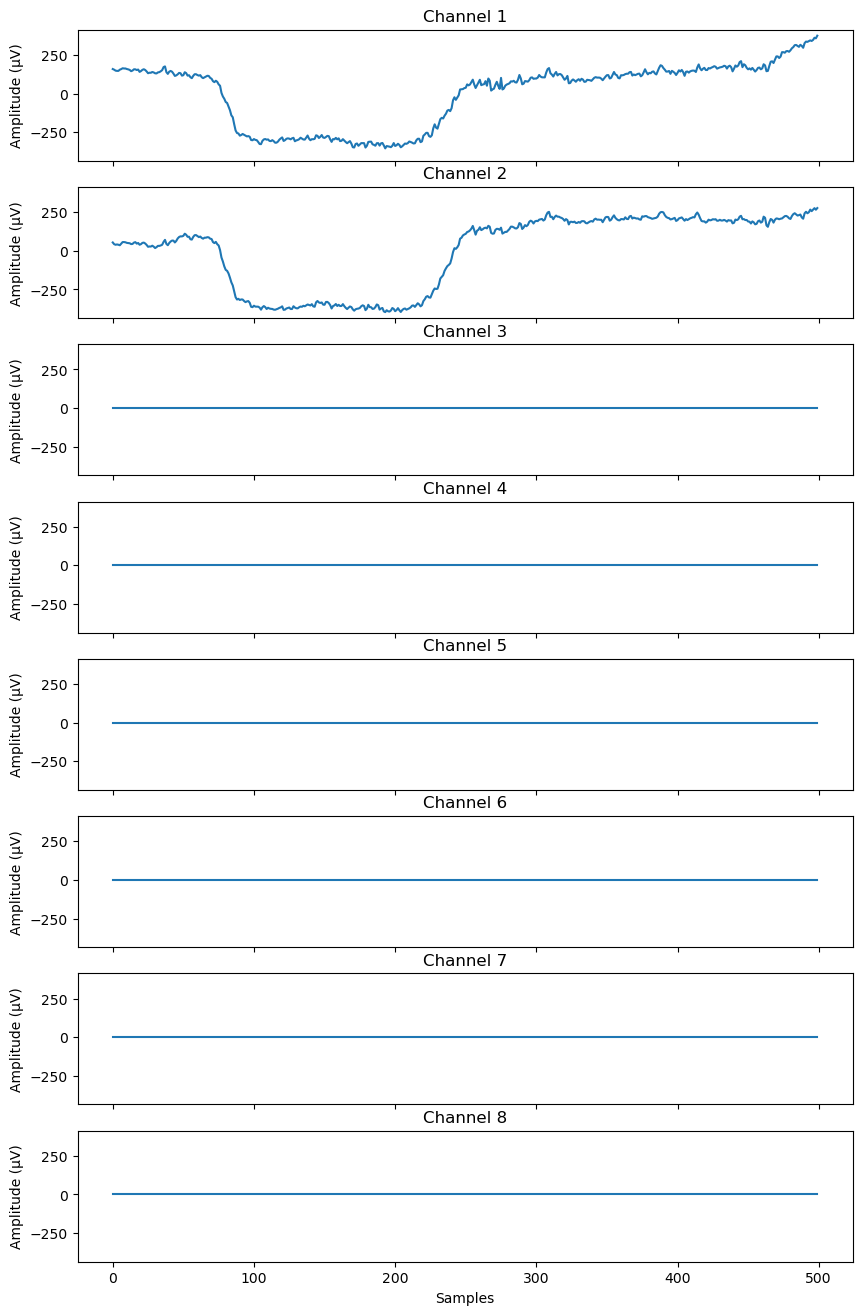

In [12]:
# Now let's plot the results
num_channels = eeg_data_dc_removed.shape[0]
num_samples = eeg_data_dc_removed.shape[1]

fig, axes = plt.subplots(num_channels, 1, figsize=(10, 2 * num_channels), sharex=True, sharey=True)

for i in range(num_channels):
    axes[i].plot(eeg_data_dc_removed[i, :])
    axes[i].set_title(f'Channel {i+1}')
    axes[i].set_ylabel('Amplitude (µV)')

axes[-1].set_xlabel('Samples')

plt.show()

That looks much better!

# <a id='toc4_'></a>[Event Markers](#toc0_)

Event markers are essential in BCI systems because they indicate specific times in the EEG stream when an event occurs, such as a stimulus presentation or a button press. These markers make it possible to segment the data into epochs, or windows of EEG activity, centered around the event. Since the goal of classification is to separate meaningful brain responses from noise, event markers provide the foundation for extracting relevant EEG segments and training classifiers to distinguish between event-related activity and background or irrelevant signals.

We can add markers to the data stream by calling `insert_marker()`. The marker itself has to be a number, and will have to be decoded later on. (i.e., what does the marker number 5 mean?)

Lets make a small loop which inserts a marker every 0.5 seconds for 5 seconds.

In [13]:
for _ in range(10):  # 5 seconds / 0.5 seconds = 10 iterations
    cyton_board.insert_marker(marker=10,
                                verbose=True # You can set this to False if you don't want to print the marker value
                                )
    time.sleep(0.5)
    
# Then, lets pull the last 5 seconds of data (250 samples per second * 5 seconds = 1250 samples)
raw_data_1250 = cyton_board.get_current_board_data(num_samples = 1250)

[Board_1] Marker 10 inserted successfully.
[Board_1] Marker 10 inserted successfully.
[Board_1] Marker 10 inserted successfully.
[Board_1] Marker 10 inserted successfully.
[Board_1] Marker 10 inserted successfully.
[Board_1] Marker 10 inserted successfully.
[Board_1] Marker 10 inserted successfully.
[Board_1] Marker 10 inserted successfully.
[Board_1] Marker 10 inserted successfully.
[Board_1] Marker 10 inserted successfully.


Now, lets do our minimal processing by taking out the marker channel, and then the EEG channels normalizing the raw data.

In [15]:
# Extract marker channel (assuming it's at index 23)
marker_data = raw_data_1250[23, :]  # Single row, all time points

# Lets use the function we made earlier to extract eeg channels and normalize the data!
eeg_data_dc_offset_removed = remove_dc_offset(eeg_data)
# print((eeg_data_dc_offset_removed))

Now, lets visualize the EEG data, with a vertical line for each marker.

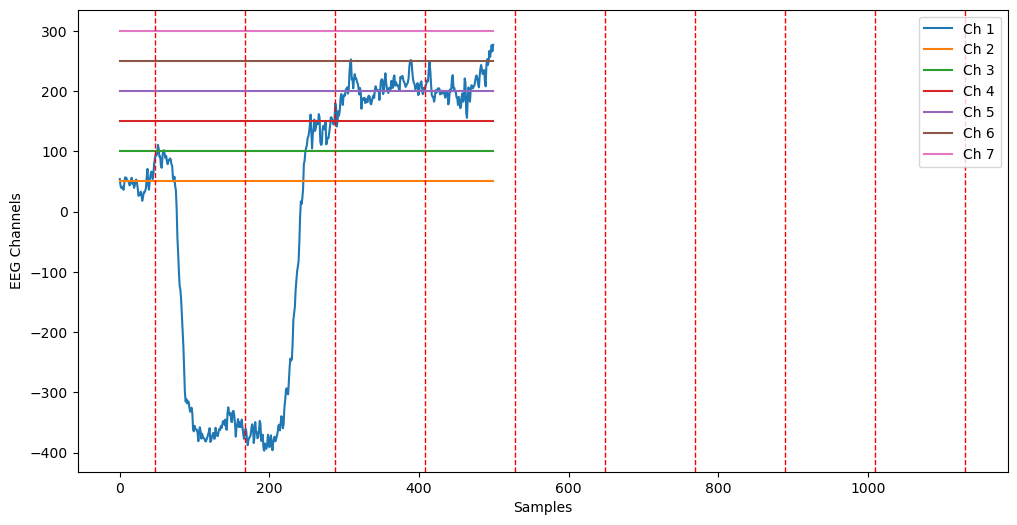

In [17]:
# Get number of samples
num_samples = eeg_data_dc_offset_removed.shape[1]

# Find marker event indices
event_indices = np.where(marker_data == 10)[0] # Find the samples where the marker is 10

# Plot EEG data with markers
plt.figure(figsize=(12, 6))
offset = 50  # Spacing between channels for easier visualization

for i in range(eeg_data_dc_offset_removed.shape[0]):
    plt.plot(eeg_data_dc_offset_removed[i] + i * offset, label=f'Ch {i+1}')

# Add vertical lines for markers
for event in event_indices:
    plt.axvline(event, color='r', linestyle='--', linewidth=1)

plt.xlabel("Samples")
plt.ylabel("EEG Channels")
plt.legend(loc="upper right")
plt.show()

# <a id='toc5_'></a>[Band Powers & Engagement Index](#toc0_)

Now that we can pull and clean EEG data, the next step is turning it into a single number we can use to drive the flashcard app: an **engagement index**. This section computes band powers, then uses them to build a live engagement score with a sliding window, plus a short calibration step to normalize it per user.

## <a id='toc5_1_'></a>[Bandpowers](#toc0_)
Here I will provide an example function to compute bandpowers of the EEG data. This is a very basic implementation and can be improved upon. 
Band powers are a common feature used in EEG analysis and BCI systems. They represent the power of the EEG signal in specific frequency bands. The most common frequency bands are:
- Delta: 0.5 - 4 Hz
- Theta: 4 - 8 Hz
- Alpha: 8 - 13 Hz
- Beta: 13 - 30 Hz
- Gamma: 30 - 100 Hz

Using bandpowers - and sometimes ratios of bandpowers (e.g., alpha:beta) - can be useful features for classification.

In [18]:
from scipy.signal import welch

def compute_band_powers(eeg_data, sfreq, bands=None, nperseg=1024):
    """
    Compute band powers from EEG data using Welch's method.

    Parameters
    ----------
    eeg_data : ndarray
        EEG signal, shape (n_channels, n_samples).
    sfreq : float
        Sampling frequency in Hz.
    bands : dict, optional
        Frequency bands as {"band": (low, high)} in Hz.
        Defaults to standard EEG bands.
    nperseg : int, optional
        Length of each segment for Welch PSD.

    Returns
    -------
    band_powers : dict
        Dictionary with keys = band names, values = array of shape (n_channels,)
        containing average band power for each channel.
    """
    if bands is None:
        bands = {
            "delta": (1, 4),
            "theta": (4, 8),
            "alpha": (8, 12),
            "beta": (12, 30),
            "gamma": (30, 100),
        }

    n_channels = eeg_data.shape[0]
    band_powers = {band: np.zeros(n_channels) for band in bands}

    # Compute PSD per channel
    for ch in range(n_channels):
        freqs, psd = welch(eeg_data[ch], sfreq, nperseg=nperseg)

        for band, (low, high) in bands.items():
            idx = np.logical_and(freqs >= low, freqs <= high)
            band_powers[band][ch] = np.trapezoid(psd[idx], freqs[idx])  # integrate power

    return band_powers



# --- Example Usage: ---
sfreq = cyton_board.get_sampling_rate()

eeg_data = remove_dc_offset(cyton_board.get_current_board_data(num_samples=500))

band_powers = compute_band_powers(eeg_data, sfreq)

print("Band Powers:")
for band, powers in band_powers.items():
    print(f"{band}: {powers}")
    # You can add further processing or visualization of the band powers here


Band Powers:
delta: [147.53100264 141.54441914   0.           0.           0.
   0.           0.           0.        ]
theta: [ 6.40845041 15.30877896  0.          0.          0.          0.
  0.          0.        ]
alpha: [3.04893537 4.90629611 0.         0.         0.         0.
 0.         0.        ]
beta: [12.15724896 14.77068923  0.          0.          0.          0.
  0.          0.        ]
gamma: [25.14968942 20.6810909   0.          0.          0.          0.
  0.          0.        ]


C:\Users\Owner\AppData\Local\Temp\ipykernel_29528\984797987.py:39: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 500, using nperseg = 500
  freqs, psd = welch(eeg_data[ch], sfreq, nperseg=nperseg)


## <a id='toc5_2_'></a>[Engagement Index (real-time loop)](#toc0_)

We'll use **Pope's Engagement Index**: `beta / (alpha + theta)`, averaged over the frontal channels (Fp1, Fp2). Higher values indicate more task engagement/alertness; lower values indicate drowsiness or disengagement.

The steps are:
1. Compute a short **baseline** (resting vs. on-task) so the index is normalized per-user, since raw band power varies a lot person to person.
2. Run a **sliding window** loop that pulls the latest samples, computes band powers, and converts them into a smoothed engagement score.
3. This score is what feeds into the flashcard app's scheduling logic (shorter/longer intervals, break prompts, etc.).

In [20]:
# Frontal channels for engagement (indices into the 8-channel eeg_data array, 0-indexed: Fp1=0, Fp2=1)
FRONTAL_CHANNELS = [0, 1]

def compute_engagement_index(eeg_data, sfreq, channels=FRONTAL_CHANNELS):
    """
    Compute Pope's Engagement Index (beta / (alpha + theta)) averaged over the given channels.

    Parameters
    ----------
    eeg_data : ndarray, shape (n_channels, n_samples)
        Cleaned EEG data (DC offset removed).
    sfreq : float
        Sampling frequency in Hz.
    channels : list of int
        Which channel indices to average over (default: frontal Fp1/Fp2).

    Returns
    -------
    float
        Engagement index for this window.
    """
    band_powers = compute_band_powers(eeg_data[channels, :], sfreq)
    beta = np.mean(band_powers["beta"])
    alpha = np.mean(band_powers["alpha"])
    theta = np.mean(band_powers["theta"])
    return beta / (alpha + theta + 1e-8)  # small epsilon to avoid divide-by-zero

### Baseline calibration

Run this once at the start of a session. It records a short **resting** period (eyes open, not studying) and a short **on-task** period (actively reviewing a card) so we know roughly where this user's engagement index sits at the low and high end.

In [22]:
def record_baseline(board, sfreq, label, duration_sec=60, window_sec=1.0):
    """
    Record engagement index samples for `duration_sec` seconds and return the list of scores.
    Call this once for a resting baseline, and once for an on-task baseline.
    """
    print(f"Recording {label} baseline for {duration_sec}s...")
    scores = []
    n_windows = int(duration_sec / window_sec)
    window_samples = int(sfreq * window_sec)

    for _ in range(n_windows):
        time.sleep(window_sec)
        raw = board.get_current_board_data(num_samples=window_samples)
        eeg_data = remove_dc_offset(raw)
        score = compute_engagement_index(eeg_data, sfreq)
        scores.append(score)

    print(f"{label} baseline done. Mean: {np.mean(scores):.4f}, Std: {np.std(scores):.4f}")
    return scores


sfreq = cyton_board.get_sampling_rate()

# 1. Resting baseline -- ask the user to relax, eyes open, not thinking about anything in particular
resting_scores = record_baseline(cyton_board, sfreq, label="resting", duration_sec=60)

# 2. On-task baseline -- ask the user to actively review a flashcard (or do mental math) for this window
ontask_scores = record_baseline(cyton_board, sfreq, label="on-task", duration_sec=60)

baseline_low = np.mean(resting_scores)
baseline_high = np.mean(ontask_scores)
print(f"\nBaseline range for this user: {baseline_low:.4f} (low) -> {baseline_high:.4f} (high)")

Recording resting baseline for 60s...


C:\Users\Owner\AppData\Local\Temp\ipykernel_29528\984797987.py:39: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 250, using nperseg = 250
  freqs, psd = welch(eeg_data[ch], sfreq, nperseg=nperseg)


resting baseline done. Mean: 0.8159, Std: 1.6249
Recording on-task baseline for 60s...
on-task baseline done. Mean: 0.5771, Std: 0.6771

Baseline range for this user: 0.8159 (low) -> 0.5771 (high)


### Real-time sliding-window loop

This is the loop the flashcard app runs continuously while a card is on screen: pull the latest window, compute the engagement index, normalize it against the baseline, and smooth it with a rolling average so a single blink or jaw clench doesn't spike the score. `insert_marker()` is used here to tag when each card was shown, so engagement scores can later be aligned back to specific cards.

Swap the `print(...)` at the bottom for however you want to hand the score off to the app (write to a local queue/websocket, append to a shared list, etc.).

In [25]:
from collections import deque

def normalize_engagement(raw_score, baseline_low, baseline_high):
    """Scale a raw engagement index to roughly 0-1 using the user's baseline range."""
    span = max(baseline_high - baseline_low, 1e-8)
    return np.clip((raw_score - baseline_low) / span, 0, 1)


def run_engagement_loop(board, sfreq, baseline_low, baseline_high,
                         window_sec=1.0, smoothing_windows=4, card_marker=1,
                         max_iterations=None):
    """
    Continuously compute a smoothed, normalized engagement score.

    Call cyton_board.insert_marker(card_marker) whenever a new flashcard is shown,
    so markers in the stream line up with engagement scores if you review the data later.
    """
    window_samples = int(sfreq * window_sec)
    recent_scores = deque(maxlen=smoothing_windows)

    iteration = 0
    while max_iterations is None or iteration < max_iterations:
        time.sleep(window_sec)

        raw = board.get_current_board_data(num_samples=window_samples)
        eeg_data = remove_dc_offset(raw)

        raw_score = compute_engagement_index(eeg_data, sfreq)
        norm_score = normalize_engagement(raw_score, baseline_low, baseline_high)

        recent_scores.append(norm_score)
        smoothed_score = np.mean(recent_scores)

        # --- Hand off to the app here (replace this print with your app-side call) ---
        print(f"Engagement: {smoothed_score:.3f}")

        iteration += 1

    return smoothed_score


# Example: run for 20 iterations (~20 seconds at window_sec=1.0) as a test
run_engagement_loop(cyton_board, sfreq, baseline_low, baseline_high, max_iterations=60)

C:\Users\Owner\AppData\Local\Temp\ipykernel_29528\984797987.py:39: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 250, using nperseg = 250
  freqs, psd = welch(eeg_data[ch], sfreq, nperseg=nperseg)


Engagement: 0.000
Engagement: 0.000
Engagement: 0.000
Engagement: 0.000
Engagement: 0.000
Engagement: 0.000
Engagement: 0.000
Engagement: 0.000
Engagement: 0.000
Engagement: 0.000
Engagement: 0.000
Engagement: 0.250
Engagement: 0.250
Engagement: 0.250
Engagement: 0.500
Engagement: 0.250
Engagement: 0.250
Engagement: 0.500
Engagement: 0.250
Engagement: 0.250
Engagement: 0.250
Engagement: 0.250
Engagement: 0.250
Engagement: 0.250
Engagement: 0.500
Engagement: 0.250
Engagement: 0.500
Engagement: 0.500
Engagement: 0.250
Engagement: 0.250
Engagement: 0.000
Engagement: 0.000
Engagement: 0.000
Engagement: 0.000
Engagement: 0.250
Engagement: 0.250
Engagement: 0.250
Engagement: 0.250
Engagement: 0.250
Engagement: 0.250
Engagement: 0.250
Engagement: 0.250
Engagement: 0.000
Engagement: 0.000
Engagement: 0.000
Engagement: 0.000
Engagement: 0.250
Engagement: 0.500
Engagement: 0.500
Engagement: 0.500
Engagement: 0.250
Engagement: 0.000
Engagement: 0.000
Engagement: 0.000
Engagement: 0.250
Engagement

np.float64(0.5)

Finally, lets stop streaming from the board.

In [19]:
cyton_board.stop()

[Board_1, COM5] Streaming stopped.
[Board_1, COM5] Session released.


# <a id='toc7_'></a>[Resources](#toc0_)

- [Brainflow Python Documentation](https://brainflow.readthedocs.io/en/stable/Examples.html#python)
- [MNE Python](https://mne.tools/stable/index.html)